# 📚 Books to Scrape: Web Scraping & SQL Analysis

**Author:** Mahmoud Ali

**Task:** BlueBug Python Developer Assessment

## Objective
Scrape the first 100 books (pages 1-5) into books.csv with these columns: ( title , price , rating , in_stock , url ) from [books.toscrape.com](https://books.toscrape.com) and analyze them with SQL.

## Workflow
1. **Scrape** the data into `books.csv`
2. **Load** it into SQLite
3. **Analyze** it with SQL queries

# 1. Install beautifulsoup for scraping  (Fast Library analyze HTML and extracting elements)

In [13]:
!pip install requests beautifulsoup4

#  2. Scraper
The scraper is saved as `scraper.py` so it can also be run from the terminal.

**Design choices:**
- `requests.Session` reuses one connection (faster and lighter on the server)
- `time.sleep(1)` between pages to be polite to the site
- `raise_for_status()` and a timeout so errors are not silent
- Price is converted to `float`, rating to `1-5`, stock to `True/False`

In [14]:
%%writefile scraper.py
import pandas as pd
import csv
import re
import time
from urllib.parse import urljoin

import requests
from bs4 import BeautifulSoup

BASE = "https://books.toscrape.com/catalogue/"
RATINGS = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}


def scrape_page(session, page_number):
    url = f"{BASE}page-{page_number}.html"
    response = session.get(url, timeout=10)
    response.raise_for_status()
    response.encoding = "utf-8"  

    soup = BeautifulSoup(response.text, "html.parser")
    books = []
    for card in soup.select("article.product_pod"):
        link = card.h3.a
        price_text = card.select_one("p.price_color").text
        rating_word = card.select_one("p.star-rating")["class"][1]
        availability = card.select_one("p.availability").text.lower()

        books.append({
            "title": link["title"],
            "price": float(re.sub(r"[^\d.]", "", price_text)),
            "rating": RATINGS[rating_word],
            "in_stock": "in stock" in availability,
            "url": urljoin(url, link["href"]),
        })
    return books


def main():
    all_books = []
    with requests.Session() as session:
        for page in range(1, 6):
            books = scrape_page(session, page)
            all_books.extend(books)
            print(f"Page {page}: {len(books)} books")
            time.sleep(1)  

    with open("books.csv", "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(
            f, fieldnames=["title", "price", "rating", "in_stock", "url"]
        )
        writer.writeheader()
        writer.writerows(all_books)

    print(f"Done. Saved {len(all_books)} books to books.csv")


if __name__ == "__main__":
    main()

Overwriting scraper.py


# 3. Run the Scraper

In [15]:
!python scraper.py

Page 1: 20 books
Page 2: 20 books
Page 3: 20 books
Page 4: 20 books
Page 5: 20 books
Done. Saved 100 books to books.csv


# 4. Check Data 

In [28]:
df = pd.read_csv("books.csv")
df.to_csv("books.csv", index=False, encoding="utf-8")
print(df.shape)

(100, 5)


# first 5 rows

In [29]:
df.head()

,title,price,rating,in_stock,url
0,A Light in the Attic,51.77,3,True,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,53.74,1,True,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,50.10,1,True,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,47.82,4,True,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,54.23,5,True,https://books.toscrape.com/catalogue/sapiens-a...


# last 5 rows

In [30]:
df.tail()

,title,price,rating,in_stock,url
95,Lumberjanes Vol. 3: A Terrible Plan (Lumberjan...,19.92,2,True,https://books.toscrape.com/catalogue/lumberjan...
96,"Layered: Baking, Building, and Styling Spectac...",40.11,1,True,https://books.toscrape.com/catalogue/layered-b...
97,Judo: Seven Steps to Black Belt (an Introducto...,53.90,2,True,https://books.toscrape.com/catalogue/judo-seve...
98,Join,35.67,5,True,https://books.toscrape.com/catalogue/join_902/...
99,In the Country We Love: My Family Divided,22.00,4,True,https://books.toscrape.com/catalogue/in-the-co...


# Data Sample

In [31]:
df.sample()

,title,price,rating,in_stock,url
11,Shakespeare's Sonnets,20.66,4,True,https://books.toscrape.com/catalogue/shakespea...


# Data Shape

In [18]:
print("Data Shape = ",df.shape)
print("Number of rows = ",df.shape[0])
print("Number of columns = ",df.shape[1])

Data Shape =  (100, 5)
Number of rows =  100
Number of columns =  5


# Data Information

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   title     100 non-null    object 
 1   price     100 non-null    float64
 2   rating    100 non-null    int64  
 3   in_stock  100 non-null    bool   
 4   url       100 non-null    object 
dtypes: bool(1), float64(1), int64(1), object(2)
memory usage: 3.4+ KB


# Data Describe

In [20]:
print("Describtion for Numerical_Data")
df.describe()

Describtion for Numerical_Data


,price,rating
count,100.000000,100.000000
mean,34.560700,2.930000
std,14.638531,1.423149
min,10.160000,1.000000
25%,19.897500,2.000000
50%,34.775000,3.000000
75%,47.967500,4.000000
max,58.110000,5.000000


In [21]:
print("Describtion for Categorical_Data")
df.describe(include="object")

Describtion for Categorical_Data


,title,url
count,100,100
unique,100,100
top,A Light in the Attic,https://books.toscrape.com/catalogue/a-light-i...
freq,1,1


# Check Null Values

In [22]:
df.isna().sum()

title       0
price       0
rating      0
in_stock    0
url         0
dtype: int64

# Check Duplicated Values

In [25]:
print("Duplicated_values = ",df.duplicated().sum())

Duplicated_values =  0


# Analysis by python

# 1. total_price

In [33]:
print ("total_price = ",df["price"].sum())

total_price =  3456.07


# 2. column in_stock counts

In [68]:
df["in_stock"].value_counts()

in_stock
True    100
Name: count, dtype: int64

# 3. Rating_Distribution

In [42]:
Rating_Distribution = df["rating"].value_counts()
Rating_Distribution

rating
3    22
1    22
5    19
2    19
4    18
Name: count, dtype: int64

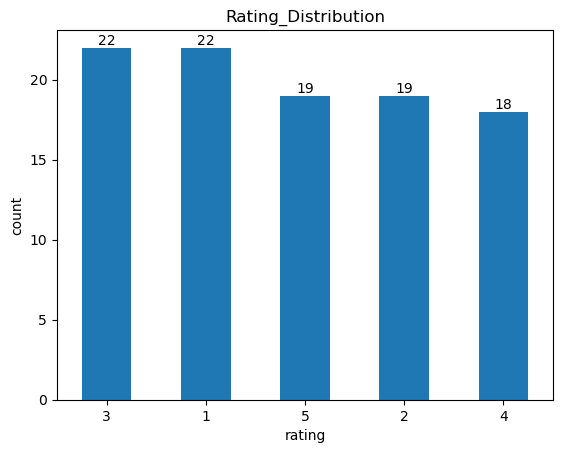

In [45]:
import matplotlib.pyplot as plt
Rating_Distribution = df["rating"].value_counts().plot(kind="bar")
for container in Rating_Distribution.containers:
    Rating_Distribution.bar_label(container)
plt.title("Rating_Distribution")
plt.xticks(rotation=360)
plt.ylabel("count")
plt.show()

# 4. Average price for each rating

In [46]:
avg_price_rating = df.groupby("rating")["price"].mean()
avg_price_rating

rating
1    35.519545
2    35.909474
3    36.839091
4    33.981667
5    30.012105
Name: price, dtype: float64

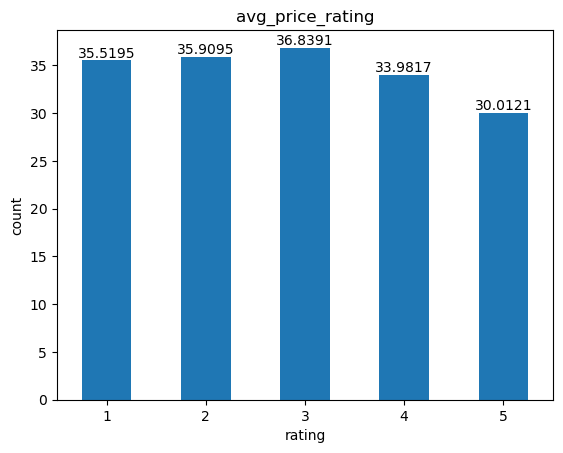

In [48]:
avg_price_rating = df.groupby("rating")["price"].mean().plot(kind="bar")
for container in avg_price_rating.containers:
    avg_price_rating.bar_label(container)
plt.title("avg_price_rating")
plt.xticks(rotation=360)
plt.ylabel("count")
plt.show()

# 5. The 5 most expensive books rated 4 or 5

In [58]:
df[df["rating"].isin([4, 5])].nlargest(5, "price")[["title", "price", "rating"]]

,title,price,rating
68,The Death of Humanity: and the Case for Life,58.11,4
58,The Past Never Ends,56.50,4
4,Sapiens: A Brief History of Humankind,54.23,5
13,Scott Pilgrim's Precious Little Life (Scott Pi...,52.29,5
38,Behind Closed Doors,52.22,4


# 6 .How many books are out of stock, per rating

In [69]:
books_out_of_stock = (df.assign(out_of_stock=(df["in_stock"] == False)).groupby("rating")["out_of_stock"].sum().reset_index())
books_out_of_stock

,rating,out_of_stock
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


# Analysis by SQLite Library

In [73]:
import sqlite3

conn = sqlite3.connect("books.db")
df.to_sql("books", conn, if_exists="replace", index=False)

pd.read_sql("Select * from books", conn)

,title,price,rating,in_stock,url
0,A Light in the Attic,51.77,3,1,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,53.74,1,1,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,50.10,1,1,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,47.82,4,1,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,54.23,5,1,https://books.toscrape.com/catalogue/sapiens-a...
...,...,...,...,...,...
95,Lumberjanes Vol. 3: A Terrible Plan (Lumberjan...,19.92,2,1,https://books.toscrape.com/catalogue/lumberjan...
96,"Layered: Baking, Building, and Styling Spectac...",40.11,1,1,https://books.toscrape.com/catalogue/layered-b...
97,Judo: Seven Steps to Black Belt (an Introducto...,53.90,2,1,https://books.toscrape.com/catalogue/judo-seve...
98,Join,35.67,5,1,https://books.toscrape.com/catalogue/join_902/...


# 1. Average price for each rating

In [76]:
pd.read_sql("Select rating , avg(price)  from books group by rating ", conn)

,rating,avg(price)
0,1,35.519545
1,2,35.909474
2,3,36.839091
3,4,33.981667
4,5,30.012105


# 2. The 5 most expensive books rated 4 or 5

In [81]:
pd.read_sql("Select title , price , rating from books where rating >= 4 order by price Desc limit 5 ",conn)

,title,price,rating
0,The Death of Humanity: and the Case for Life,58.11,4
1,The Past Never Ends,56.50,4
2,Sapiens: A Brief History of Humankind,54.23,5
3,Scott Pilgrim's Precious Little Life (Scott Pi...,52.29,5
4,Behind Closed Doors,52.22,4


# 3. How many books are out of stock, per rating

In [84]:
pd.read_sql("Select rating , sum(case when in_stock = 0 then 1 else 0 end ) as out_stock from books group by rating order by rating", conn)

,rating,out_stock
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


# SQLite

In [94]:
%%writefile queries.sql
-- 1. Average price for each rating
SELECT rating, ROUND(AVG(price), 2) AS avg_price
FROM books
GROUP BY rating
ORDER BY rating;

-- 2. The 5 most expensive books rated 4 or 5
SELECT title, price, rating
FROM books
WHERE rating >= 4
ORDER BY price DESC
LIMIT 5;

-- 3. Out-of-stock books per rating
SELECT rating,
       SUM(CASE WHEN in_stock = 0 THEN 1 ELSE 0 END) AS out_of_stock
FROM books
GROUP BY rating
ORDER BY rating;

Overwriting queries.sql


# README

In [91]:
%%writefile README.md
# Books to Scrape: Scraping & SQL Task

Scrapes the first 100 books (pages 1-5) from books.toscrape.com, saves them to `books.csv`, and analyzes them with SQL.

## Files
- `scraper.py`: the scraper (requests + BeautifulSoup) +Analysis by python with pandas and SQLite
- `books.csv`: the 100 scraped books
- `queries.sql`: SQLite version of the 3 queries
- `queries_ssms.sql`: SQL Server (T-SQL) version

## How to run
    pip install requests beautifulsoup4
    python scraper.py

## Five lines

**What broke, or took longer than expected?**
1. The pound sign could show up as garbage, so I set the response encoding to UTF-8.
2. Excel showed the whole CSV in one column because of my Windows list separator; the file itself was fine (I checked it with Python).
3. SQL Server rejected LIMIT (needs TOP), and in_stock was imported as text, so comparing it with 0 failed.
4. Every book is in stock, so the out-of-stock query returns zeros; I checked that this is the real data, not a bug.

**If the site blocked me after 50 requests, what would I change?**
5. I would add random delays, retry with backoff on 429/503, save results page by page so I can resume, and send a clear User-Agent.

Overwriting README.md
